# 04 – Logistic Regression

Review 1 Part-A classification.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from classification_utils import (
    load_data,
    prepare_target,
    make_split,
    make_preprocessor,
    make_pipeline
)

# Load and prepare dataset
df, feature_cols = prepare_target(load_data())

# Stratified 80:20 split
X_train, X_test, y_train, y_test, le = make_split(
    df,
    feature_cols
)

# Preprocessing
preprocessor = make_preprocessor(X_train)

# Logistic Regression model
model = LogisticRegression(
    max_iter=3000,
    random_state=42
)

# Complete preprocessing + model pipeline
pipe = make_pipeline(
    model,
    preprocessor
)

# Train
pipe.fit(X_train, y_train)

# Predict
y_pred = pipe.predict(X_test)

# Evaluation metrics
metrics = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(
        y_test, y_pred,
        average="weighted",
        zero_division=0
    ),
    "Recall": recall_score(
        y_test, y_pred,
        average="weighted",
        zero_division=0
    ),
    "Weighted F1": f1_score(
        y_test, y_pred,
        average="weighted",
        zero_division=0
    )
}

# Display metrics
results = pd.DataFrame([metrics])

display(
    results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "Weighted F1": "{:.4f}"
    })
)

# Classification report
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=le.classes_,
        zero_division=0
    )
)

,Model,Accuracy,Precision,Recall,Weighted F1
0,Logistic Regression,0.6787,0.6853,0.6787,0.6804


Classification Report:
              precision    recall  f1-score   support

       Bumps       0.61      0.53      0.57        81
   Dirtiness       0.64      0.64      0.64        11
    K_Scatch       0.92      0.87      0.89        78
Other_Faults       0.59      0.65      0.62       135
      Pastry       0.51      0.56      0.54        32
      Stains       0.79      0.79      0.79        14
   Z_Scratch       0.83      0.76      0.79        38

    accuracy                           0.68       389
   macro avg       0.70      0.69      0.69       389
weighted avg       0.69      0.68      0.68       389



## Confusion Matrix

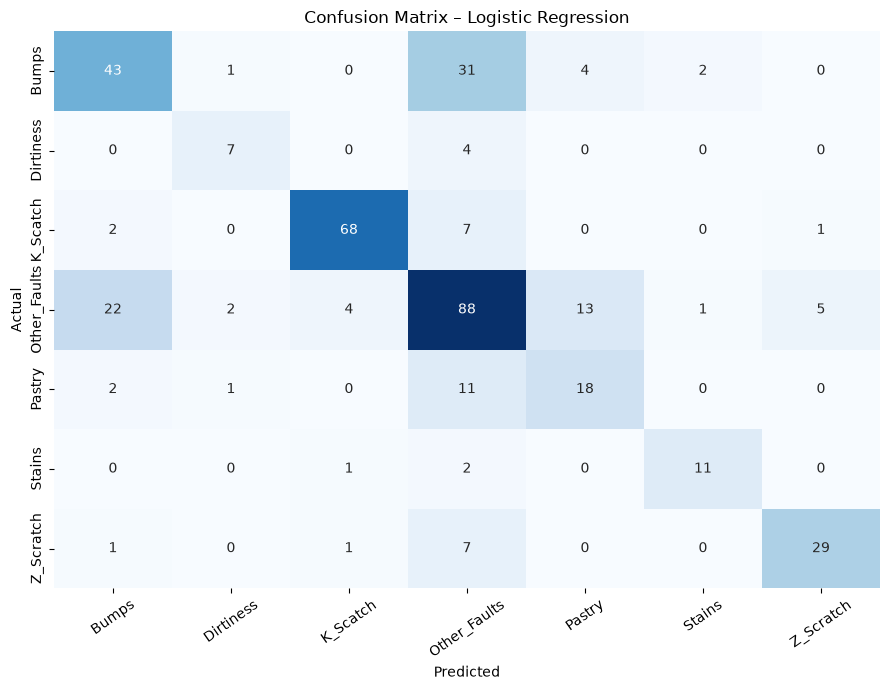

In [3]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Confusion Matrix – Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

### Observation

The off-diagonal entries of the confusion matrix indicate the confusions made by the fault types whereas the diagonal entries are the correctly predicted faults. The accuracy, weighted precision, weighted recall, and weighted F1 measures mentioned above summarize the results obtained from the same test set.